# Chapter 19: Elliptic and Hyperbolic Geometry

Source orientation: printed Volume II pages 318-348; PDF pages 327-357. I read the assigned source span for structure and terminology before editing. The PDF pages are image-only for `pdftotext`, so the span was inspected from temporary rendered pages, not copied into this notebook.

Chapter goal: compare elliptic geometry and hyperbolic geometry by making their model choices visible. The same abstract point, geodesic, distance, area, or isometry can look different after a quotient or a coordinate change. This notebook treats each model as a computational contract: state the map, draw what it does, then check the invariant it is supposed to preserve.

The source route is: elliptic space as the antipodal quotient of the unit sphere, hyperbolic space from the projective/Klein ball model, the fundamental distance formula, the isometry group, canonical measure, the Poincare conformal disk, and other transported models such as the half-plane.

## Computational Translation Guide

| Book idea | Computational representation | What the visual should make inspectable |
| --- | --- | --- |
| Elliptic point | A line through the origin, represented by a unit vector `x` and its antipode `-x` | The quotient identifies antipodal lifts, so distance is `arccos(abs(x dot y))` and the diameter is `pi/2`. |
| Elliptic line | A projective line, drawn as a great circle modulo antipodes | The sphere picture has duplicate lifts; the elliptic object does not. |
| Hyperbolic projective/Klein ball | A Euclidean unit disk with geodesics drawn as chords | Chords are model coordinates, not Euclidean shortest paths. |
| Poincare disk | The same unit disk after a nonlinear radial map | Geodesics become circular arcs orthogonal to the boundary and angles are visually Euclidean. |
| Disk isometry | A complex fractional-linear map preserving the unit disk | Hyperbolic distances stay fixed while Euclidean radii, chord lengths, and locations move. |
| Canonical measure | A density over Euclidean coordinate area | The area element grows near the ideal boundary, and different models assign different Euclidean radii to the same hyperbolic radius. |

Library routing: Matplotlib is used for durable 2D/3D comparison diagrams; Plotly is used for an interactive model-change artifact; SymPy records a symbolic area-density scaffold; NumPy supplies the projective, radial, and Mobius computations. This is intentionally not Matplotlib-only: the HTML model comparison lets the learner inspect corresponding points on the Klein chord and Poincare arc.

In [1]:
from pathlib import Path
import sys

search_starts = [Path.cwd(), Path.cwd() / "Geometry-II"]
for parent in Path.cwd().parents:
    search_starts.extend([parent, parent / "Geometry-II"])

BOOK_ROOT = None
for candidate in search_starts:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate.resolve()
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the Geometry II book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

CHAPTER = 19
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / f"chapter-{CHAPTER:02d}"
FIGURE_ROOT = ARTIFACT_ROOT / "figures"
PLOT_ROOT = ARTIFACT_ROOT / "plots"
TABLE_ROOT = ARTIFACT_ROOT / "tables"
CHECK_ROOT = ARTIFACT_ROOT / "checks"
for root in [FIGURE_ROOT, PLOT_ROOT, TABLE_ROOT, CHECK_ROOT]:
    root.mkdir(parents=True, exist_ok=True)

print(f"Geometry II root: {BOOK_ROOT}")

Geometry II root: D:\Geometry\Geometry-II


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

from IPython.display import Markdown, display
from utils.artifacts import assert_artifacts, display_artifact, relative_to_book, save_csv, save_json, save_plotly_html
from utils.geometry import circle_orthogonality, disk_rotation, poincare_distance, spherical_distance
from utils.plotting import COLORS, new_3d_axes, new_axes, plot_points, plot_unit_circle, save_figure, set_equal_3d

generated_artifacts = []
computed_checks = {}


def unit(v):
    v = np.asarray(v, dtype=float)
    n = np.linalg.norm(v)
    if n <= 1e-12:
        raise ValueError("zero vector has no direction")
    return v / n


def elliptic_distance(x, y):
    x = unit(x)
    y = unit(y)
    return float(np.arccos(np.clip(abs(np.dot(x, y)), -1.0, 1.0)))


def great_circle_segment(x, y, count=160):
    x = unit(x)
    y = unit(y)
    if np.dot(x, y) < 0:
        y = -y
    dot = float(np.clip(np.dot(x, y), -1.0, 1.0))
    theta = math.acos(dot)
    if theta <= 1e-12:
        return np.repeat(x[None, :], count, axis=0)
    direction = unit(y - dot * x)
    t = np.linspace(0.0, theta, count)
    return np.cos(t)[:, None] * x + np.sin(t)[:, None] * direction


def klein_to_poincare(k):
    k = np.asarray(k, dtype=float)
    r2 = np.sum(k * k, axis=-1, keepdims=True)
    return k / (1.0 + np.sqrt(np.maximum(1.0 - r2, 0.0)))


def poincare_to_klein(p):
    p = np.asarray(p, dtype=float)
    r2 = np.sum(p * p, axis=-1, keepdims=True)
    return 2.0 * p / (1.0 + r2)


def klein_distance(k, l):
    k = np.asarray(k, dtype=float)
    l = np.asarray(l, dtype=float)
    numerator = 1.0 - float(np.dot(k, l))
    denominator = math.sqrt((1.0 - float(np.dot(k, k))) * (1.0 - float(np.dot(l, l))))
    return float(np.arccosh(np.clip(numerator / denominator, 1.0, None)))


def poincare_arc_center_radius(u, v):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    if abs(np.cross(u, v)) <= 1e-12:
        return None, None
    mat = 2.0 * np.vstack([u, v])
    rhs = np.array([np.dot(u, u) + 1.0, np.dot(v, v) + 1.0])
    center = np.linalg.solve(mat, rhs)
    radius = math.sqrt(max(float(np.dot(center, center) - 1.0), 0.0))
    return center, radius


def poincare_geodesic_points(u, v, count=220):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    center, radius = poincare_arc_center_radius(u, v)
    if center is None:
        return np.linspace(u, v, count)
    a0 = math.atan2(u[1] - center[1], u[0] - center[0])
    a1 = math.atan2(v[1] - center[1], v[0] - center[0])
    delta = (a1 - a0 + math.pi) % (2.0 * math.pi) - math.pi
    angles = a0 + np.linspace(0.0, delta, count)
    pts = center + radius * np.column_stack([np.cos(angles), np.sin(angles)])
    if np.max(np.linalg.norm(pts, axis=1)) > 1.0 + 1e-8:
        delta = delta - 2.0 * math.pi if delta > 0 else delta + 2.0 * math.pi
        angles = a0 + np.linspace(0.0, delta, count)
        pts = center + radius * np.column_stack([np.cos(angles), np.sin(angles)])
    return pts


def mobius_disk(z, a=0.0 + 0.0j, theta=0.0):
    z = np.asarray(z, dtype=complex)
    return np.exp(1j * theta) * (z + a) / (1.0 + np.conjugate(a) * z)


def xy_to_complex(points):
    pts = np.asarray(points, dtype=float)
    return pts[..., 0] + 1j * pts[..., 1]


def complex_to_xy(z):
    z = np.asarray(z, dtype=complex)
    return np.column_stack([z.real.ravel(), z.imag.ravel()]).reshape(z.shape + (2,))


def add_disk_boundary(ax, *, label="ideal boundary"):
    plot_unit_circle(ax, color=COLORS["ink"], label=label)
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

def show_artifact(path, *, width=760, height=520):
    candidate = Path(path)
    if candidate.suffix.lower() == ".json":
        display(Markdown(f"`{relative_to_book(candidate, BOOK_ROOT)}`"))
    else:
        display_artifact(candidate, width=width, height=height)


## Refreshed Visualization Storyboard

The improvement pass uses the following storyboard. Each item names the model comparison, artifact, learner inspection target, and invariant. The JSON copy is saved so later QC can audit the intended visuals without reading every code cell.

This visualization storyboard is also the notebook's proof scaffold. The quotient figure checks the definition of elliptic distance against sign changes of the sphere lift. The model-comparison figure checks that a projective chord and a conformal circular arc are two coordinate descriptions of one hyperbolic geodesic. The isometry figure checks which quantities survive a disk automorphism. The area figure checks that boundary growth belongs to the invariant measure rather than to a plotting accident. Each visual therefore has a corresponding residual: if the picture is changed in a way that respects the hypotheses, the residual should remain small; if a model artifact is mistaken for an invariant, one of the checks should expose the mistake.

In [3]:
storyboard = {
    "chapter_goal": "Compare elliptic and hyperbolic geometry by separating intrinsic quantities from model artifacts.",
    "source_span_read": {
        "printed_volume_ii_pages": "318-348",
        "pdf_pages": "327-357",
        "source_pdf": "Geometry-II/Geometry-II.pdf",
        "source_map_note": "pdf_page = printed_page + 9; pages were image-only for pdftotext and inspected from temporary renders"
    },
    "visual_sequence": [
        {
            "concept": "elliptic space as an antipodal sphere quotient",
            "artifact": "figures/elliptic-antipodal-quotient.png",
            "inspection_target": "a point has two spherical lifts but one elliptic identity",
            "validation": "distance uses arccos(abs(dot)) and antipodal lifts have quotient distance zero"
        },
        {
            "concept": "Klein chord versus Poincare circular arc",
            "artifact": "figures/klein-poincare-geodesic-comparison.png and plots/klein-poincare-geodesic-map.html",
            "inspection_target": "the same geodesic is straight in Klein coordinates and curved in Poincare coordinates",
            "validation": "radial map round-trip, chord-to-arc deviation, and boundary orthogonality residual"
        },
        {
            "concept": "disk isometries preserve hyperbolic distance, not Euclidean placement",
            "artifact": "figures/poincare-disk-isometry-distance-invariance.png",
            "inspection_target": "points move and Euclidean distances change while Poincare distances stay fixed",
            "validation": "pairwise hyperbolic distance residual after a disk automorphism"
        },
        {
            "concept": "canonical area and model-dependent Euclidean radius",
            "artifact": "figures/hyperbolic-area-density-model-artifacts.png and tables/hyperbolic-area-growth.csv",
            "inspection_target": "equal hyperbolic radii occupy different Euclidean radii in Klein and Poincare charts",
            "validation": "Klein and Poincare area formulas agree as functions of hyperbolic radius"
        }
    ],
    "library_routing": {
        "matplotlib": "durable static quotient, disk, isometry, and area diagrams",
        "plotly": "interactive paired model-change artifact for corresponding Klein and Poincare points",
        "sympy": "symbolic area-density scaffold",
        "numpy": "projective, radial, Mobius, and distance computations"
    },
    "proof_visualization_strategy": "Use invariant trackers rather than copied proof diagrams: quotient distance, Lorentz/Klein distance, Poincare orthogonality, Mobius distance preservation, and area formula agreement.",
}

storyboard_path = CHECK_ROOT / "chapter-19-visual-storyboard.json"
save_json(storyboard, storyboard_path)
generated_artifacts.append(storyboard_path)
show_artifact(storyboard_path)

`artifacts/chapter-19/checks/chapter-19-visual-storyboard.json`

## 1. Elliptic Geometry: Quotient Before Picture

In the elliptic part of the chapter, a point is not a single point on the unit sphere. It is a one-dimensional direction, so the two lifts `x` and `-x` represent the same elliptic point. The metric records the smaller spherical angle after that identification:

`d_E([x], [y]) = arccos(abs(x dot y))`.

The visual below deliberately keeps both spherical lifts visible. The learner should inspect two facts: first, an elliptic point has two displayed lifts; second, a shortest elliptic segment is a great-circle arc after choosing the lift of the endpoint that makes the angle at most `pi/2`.

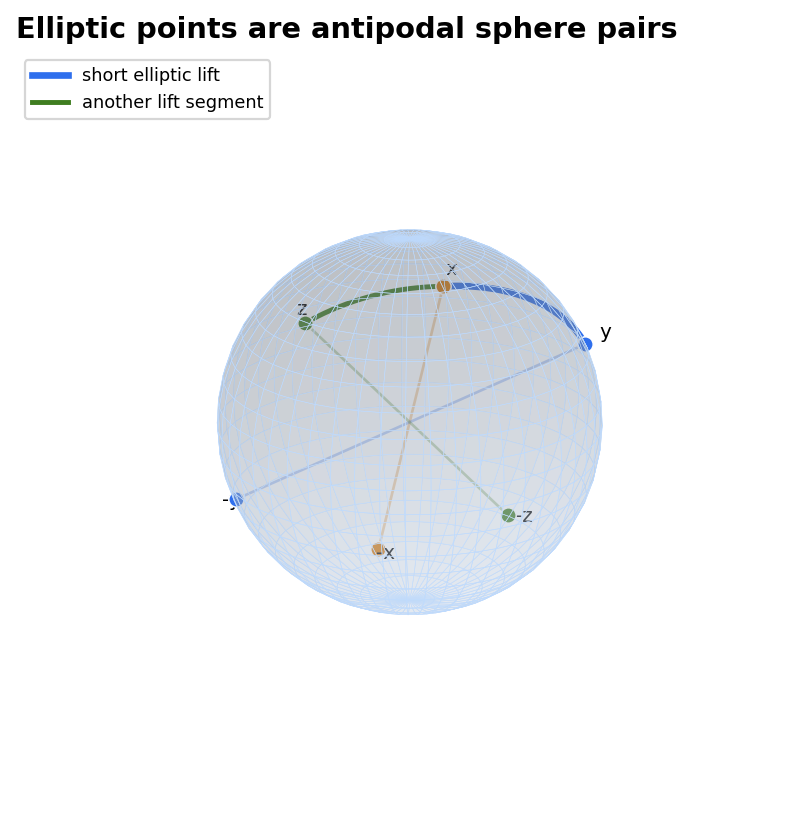

`artifacts/chapter-19/checks/elliptic-quotient-checks.json`

In [4]:
# Elliptic quotient figure.
x = unit(np.array([0.24, 0.40, 0.884]))
y = unit(np.array([-0.58, 0.70, 0.42]))
z = unit(np.array([0.70, -0.12, 0.704]))
arc_xy = great_circle_segment(x, y)
arc_xz = great_circle_segment(x, z)

sx, sy, sz = [], [], []
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 25)
U, V = np.meshgrid(u, v)
SX = np.cos(U) * np.sin(V)
SY = np.sin(U) * np.sin(V)
SZ = np.cos(V)

fig = plt.figure(figsize=(8.0, 6.2))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SX, SY, SZ, color="#dbeafe", edgecolor="#bfdbfe", linewidth=0.25, alpha=0.25)
ax.plot(arc_xy[:, 0], arc_xy[:, 1], arc_xy[:, 2], color=COLORS["blue"], linewidth=3.0, label="short elliptic lift")
ax.plot(arc_xz[:, 0], arc_xz[:, 1], arc_xz[:, 2], color=COLORS["green"], linewidth=2.2, label="another lift segment")

lift_points = np.vstack([x, -x, y, -y, z, -z])
labels = ["x", "-x", "y", "-y", "z", "-z"]
colors = [COLORS["orange"], COLORS["orange"], COLORS["blue"], COLORS["blue"], COLORS["green"], COLORS["green"]]
for point, label, color in zip(lift_points, labels, colors):
    ax.scatter(point[0], point[1], point[2], s=48, color=color, edgecolor="white", linewidth=0.7)
    ax.text(point[0] * 1.08, point[1] * 1.08, point[2] * 1.08, label, fontsize=9)

# Lines through antipodal lifts expose the quotient relation.
for point, color in [(x, COLORS["orange"]), (y, COLORS["blue"]), (z, COLORS["green"] )]:
    ax.plot([-point[0], point[0]], [-point[1], point[1]], [-point[2], point[2]], color=color, alpha=0.35, linewidth=1.2)

ax.set_title("Elliptic points are antipodal sphere pairs", loc="left", fontsize=13, fontweight="bold")
ax.set_axis_off()
set_equal_3d(ax, np.vstack([SX.ravel(), SY.ravel(), SZ.ravel()]).T, radius=1.18)
ax.view_init(elev=20, azim=38)
ax.legend(loc="upper left", fontsize=8)
elliptic_path = FIGURE_ROOT / "elliptic-antipodal-quotient.png"
save_figure(fig, elliptic_path)
generated_artifacts.append(elliptic_path)

elliptic_checks = {
    "spherical_distance_x_to_minus_x": spherical_distance(x, -x),
    "elliptic_distance_x_to_minus_x": elliptic_distance(x, -x),
    "elliptic_distance_xy": elliptic_distance(x, y),
    "elliptic_distance_sign_invariance_residual": abs(elliptic_distance(x, y) - elliptic_distance(-x, y)),
    "elliptic_diameter_sample_pi_over_2": elliptic_distance(np.array([1.0, 0.0, 0.0]), np.array([0.0, 1.0, 0.0])),
}
computed_checks["elliptic_quotient"] = elliptic_checks
elliptic_check_path = CHECK_ROOT / "elliptic-quotient-checks.json"
save_json(elliptic_checks, elliptic_check_path)
generated_artifacts.append(elliptic_check_path)

show_artifact(elliptic_path)
show_artifact(elliptic_check_path)

## 2. Projective Hyperbolic Space: Klein Chords And Poincare Arcs

The hyperbolic part begins projectively. In the Klein ball, geodesics are the visible chords of the unit disk. The Poincare disk is reached by a nonlinear radial change of coordinates:

`K = 2P/(1 + |P|^2)`, and `P = K/(1 + sqrt(1 - |K|^2))`.

This map does not change the underlying hyperbolic line, but it changes its Euclidean appearance. A straight chord in Klein coordinates becomes a circular arc orthogonal to the ideal boundary in Poincare coordinates. That is the first major model artifact to inspect: straightness belongs to the chart, not to the abstract geodesic.

C:\Users\rahul\AppData\Local\Temp\ipykernel_24980\3835976998.py:68: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if abs(np.cross(u, v)) <= 1e-12:


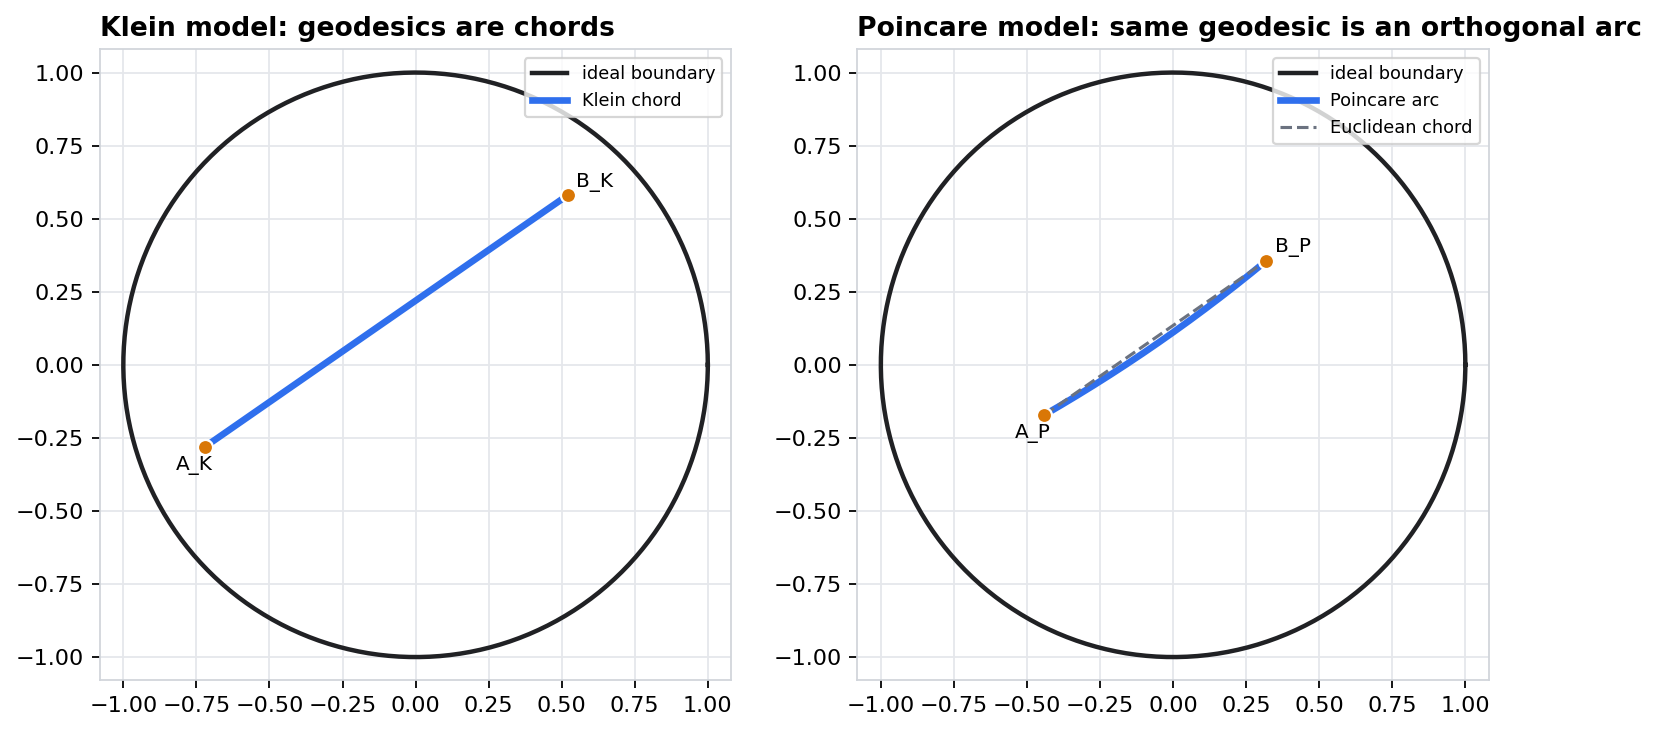

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


`artifacts/chapter-19/checks/klein-poincare-model-checks.json`

In [5]:
# Same hyperbolic geodesic in Klein and Poincare coordinates.
k_a = np.array([-0.72, -0.28])
k_b = np.array([0.52, 0.58])
line_t = np.linspace(0.0, 1.0, 240)
klein_chord = (1.0 - line_t[:, None]) * k_a + line_t[:, None] * k_b
poincare_curve = klein_to_poincare(klein_chord)
p_a, p_b = klein_to_poincare(np.vstack([k_a, k_b]))
poincare_arc = poincare_geodesic_points(p_a, p_b, count=240)
center, radius = poincare_arc_center_radius(p_a, p_b)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))
for ax, title in zip(axes, ["Klein model: geodesics are chords", "Poincare model: same geodesic is an orthogonal arc"]):
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e5e7eb", linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color("#d1d5db")
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
    plot_unit_circle(ax, color=COLORS["ink"], label="ideal boundary")
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)

axes[0].plot(klein_chord[:, 0], klein_chord[:, 1], color=COLORS["blue"], linewidth=3.0, label="Klein chord")
axes[0].scatter([k_a[0], k_b[0]], [k_a[1], k_b[1]], color=COLORS["orange"], s=46, edgecolor="white", zorder=5)
axes[0].text(k_a[0] - 0.1, k_a[1] - 0.08, "A_K", fontsize=9)
axes[0].text(k_b[0] + 0.03, k_b[1] + 0.03, "B_K", fontsize=9)

axes[1].plot(poincare_arc[:, 0], poincare_arc[:, 1], color=COLORS["blue"], linewidth=3.0, label="Poincare arc")
axes[1].plot([p_a[0], p_b[0]], [p_a[1], p_b[1]], color=COLORS["gray"], linestyle="--", linewidth=1.4, label="Euclidean chord")
axes[1].scatter([p_a[0], p_b[0]], [p_a[1], p_b[1]], color=COLORS["orange"], s=46, edgecolor="white", zorder=5)
axes[1].text(p_a[0] - 0.1, p_a[1] - 0.08, "A_P", fontsize=9)
axes[1].text(p_b[0] + 0.03, p_b[1] + 0.03, "B_P", fontsize=9)

for ax in axes:
    ax.legend(loc="upper right", fontsize=8)

comparison_path = FIGURE_ROOT / "klein-poincare-geodesic-comparison.png"
save_figure(fig, comparison_path)
generated_artifacts.append(comparison_path)

# Interactive paired view: corresponding parameter values on the chord and arc share a color/hover index.
unit_theta = np.linspace(0, 2 * np.pi, 360)
fig_html = make_subplots(rows=1, cols=2, subplot_titles=("Klein chord", "Poincare image"))
for col in [1, 2]:
    fig_html.add_trace(go.Scatter(x=np.cos(unit_theta), y=np.sin(unit_theta), mode="lines", name="ideal boundary", line=dict(color="#202124", width=2), showlegend=(col == 1)), row=1, col=col)
fig_html.add_trace(go.Scatter(x=klein_chord[:, 0], y=klein_chord[:, 1], mode="lines", name="Klein geodesic", line=dict(color="#2f6fed", width=4)), row=1, col=1)
fig_html.add_trace(go.Scatter(x=poincare_curve[:, 0], y=poincare_curve[:, 1], mode="lines", name="Poincare image", line=dict(color="#2f6fed", width=4)), row=1, col=2)
fig_html.add_trace(go.Scatter(x=klein_chord[::16, 0], y=klein_chord[::16, 1], mode="markers", name="same parameters", marker=dict(color=line_t[::16], colorscale="Viridis", size=8, showscale=True, colorbar=dict(title="t"))), row=1, col=1)
fig_html.add_trace(go.Scatter(x=poincare_curve[::16, 0], y=poincare_curve[::16, 1], mode="markers", name="mapped parameters", marker=dict(color=line_t[::16], colorscale="Viridis", size=8, showscale=False)), row=1, col=2)
fig_html.update_xaxes(range=[-1.1, 1.1], constrain="domain")
fig_html.update_yaxes(range=[-1.1, 1.1], scaleanchor="x", scaleratio=1, row=1, col=1)
fig_html.update_yaxes(range=[-1.1, 1.1], scaleanchor="x2", scaleratio=1, row=1, col=2)
fig_html.update_layout(title="One geodesic, two disk coordinates", width=920, height=460, margin=dict(l=20, r=20, t=70, b=20))
html_path = PLOT_ROOT / "klein-poincare-geodesic-map.html"
save_plotly_html(fig_html, html_path)
generated_artifacts.append(html_path)

# Checks: the radial map is inverse to itself, and the mapped chord agrees with the orthogonal circle arc.
grid = np.array([[r * math.cos(t), r * math.sin(t)] for r in np.linspace(0.0, 0.92, 7) for t in np.linspace(0.0, 2 * np.pi, 13, endpoint=False)])
roundtrip = poincare_to_klein(klein_to_poincare(grid))
# Deviation from the circle equation is a stable way to compare the whole mapped chord with the Poincare geodesic.
arc_circle_residuals = np.linalg.norm(poincare_curve - center, axis=1) - radius
model_checks = {
    "klein_to_poincare_roundtrip_max": float(np.max(np.linalg.norm(roundtrip - grid, axis=1))),
    "poincare_arc_circle_equation_max_abs": float(np.max(np.abs(arc_circle_residuals))),
    "poincare_arc_boundary_orthogonality_residual": float(circle_orthogonality(tuple(center), radius, (0.0, 0.0), 1.0)),
    "klein_distance_AB": klein_distance(k_a, k_b),
    "poincare_distance_mapped_AB": poincare_distance(p_a, p_b),
    "distance_model_residual": klein_distance(k_a, k_b) - poincare_distance(p_a, p_b),
}
computed_checks["klein_poincare_models"] = model_checks
model_check_path = CHECK_ROOT / "klein-poincare-model-checks.json"
save_json(model_checks, model_check_path)
generated_artifacts.append(model_check_path)

show_artifact(comparison_path)
show_artifact(html_path, width=920, height=500)
show_artifact(model_check_path)

## 3. Distance Invariance Under Disk Isometries

The Poincare disk makes angles easy to see, but Euclidean coordinates still lie. A disk isometry can be written in complex notation as a fractional-linear map preserving the unit disk. Such a map moves points, changes Euclidean chord lengths, and changes Euclidean radii. The invariant is the hyperbolic distance.

The figure below applies one disk automorphism to three points and the geodesics between them. Inspect the before and after disks as Euclidean pictures, then read the JSON check: hyperbolic pairwise distances are unchanged to numerical precision while Euclidean distances are not.

C:\Users\rahul\AppData\Local\Temp\ipykernel_24980\3835976998.py:68: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if abs(np.cross(u, v)) <= 1e-12:


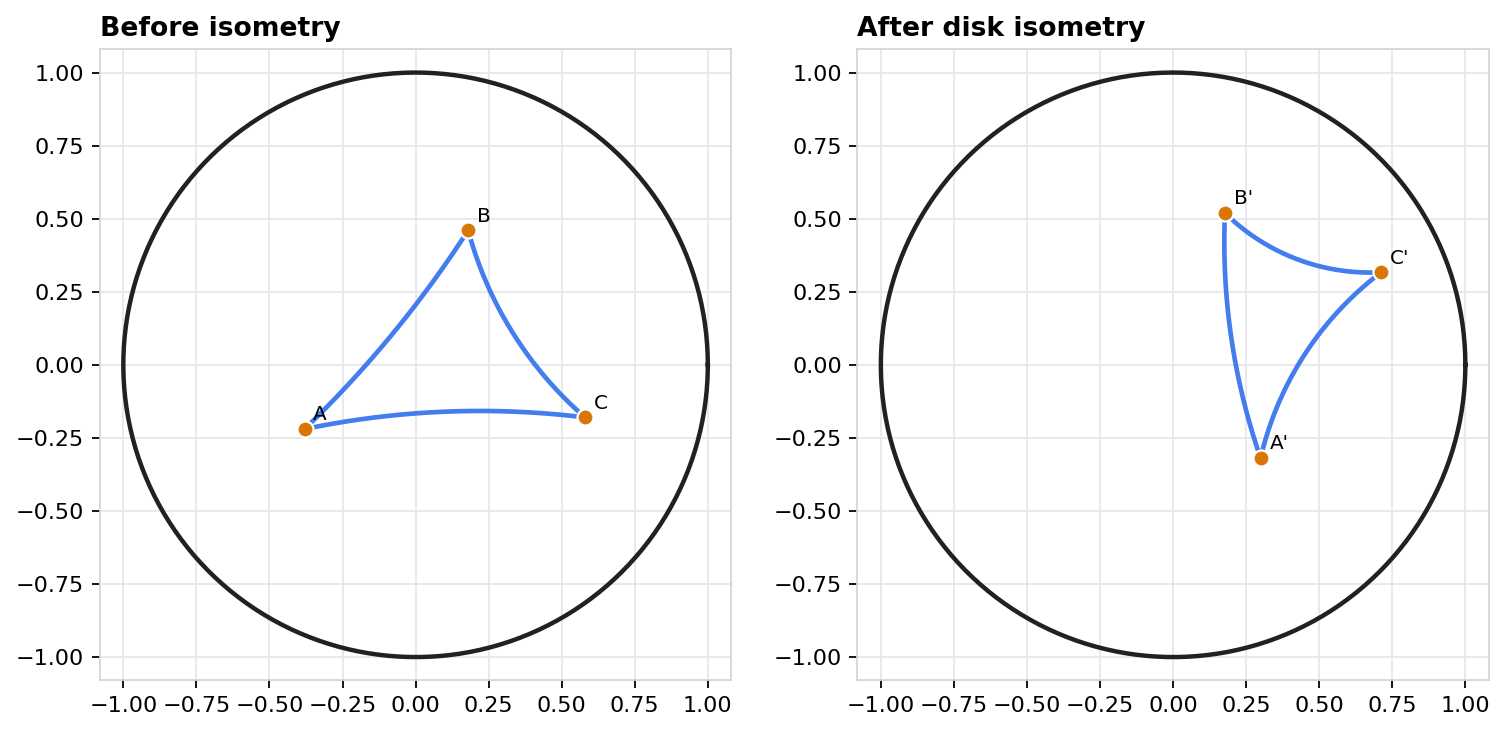

`artifacts/chapter-19/checks/poincare-isometry-invariance-checks.json`

In [6]:
points = np.array([[-0.38, -0.22], [0.18, 0.46], [0.58, -0.18]])
labels = ["A", "B", "C"]
z_points = xy_to_complex(points)
shift = 0.28 - 0.18j
angle = 0.86
z_moved = mobius_disk(z_points, a=shift, theta=angle)
moved = complex_to_xy(z_moved)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))
for ax, title, pts, suffix in [
    (axes[0], "Before isometry", points, ""),
    (axes[1], "After disk isometry", moved, "'")
]:
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, color="#e5e7eb", linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color("#d1d5db")
    ax.set_title(title, loc="left", fontsize=12, fontweight="bold")
    plot_unit_circle(ax, color=COLORS["ink"], label="ideal boundary")
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        arc = poincare_geodesic_points(pts[i], pts[j])
        ax.plot(arc[:, 0], arc[:, 1], color=COLORS["blue"], linewidth=2.1, alpha=0.9)
    ax.scatter(pts[:, 0], pts[:, 1], color=COLORS["orange"], s=52, edgecolor="white", zorder=5)
    for point, label in zip(pts, labels):
        ax.text(point[0] + 0.03, point[1] + 0.03, label + suffix, fontsize=9)
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)

isometry_path = FIGURE_ROOT / "poincare-disk-isometry-distance-invariance.png"
save_figure(fig, isometry_path)
generated_artifacts.append(isometry_path)

pairs = [(0, 1), (1, 2), (2, 0)]
hyp_before = np.array([poincare_distance(points[i], points[j]) for i, j in pairs])
hyp_after = np.array([poincare_distance(moved[i], moved[j]) for i, j in pairs])
euc_before = np.array([np.linalg.norm(points[i] - points[j]) for i, j in pairs])
euc_after = np.array([np.linalg.norm(moved[i] - moved[j]) for i, j in pairs])

# The same chapter formula also yields the hyperbolic law of cosines. Use the origin so the angle is visibly Euclidean.
q = np.array([0.44, 0.0])
r = np.array([0.22 * math.cos(1.08), 0.22 * math.sin(1.08)])
a = poincare_distance(q, r)
b = poincare_distance(np.zeros(2), r)
c = poincare_distance(np.zeros(2), q)
alpha = math.acos(np.dot(q, r) / (np.linalg.norm(q) * np.linalg.norm(r)))
law_residual = math.cosh(a) - (math.cosh(b) * math.cosh(c) - math.sinh(b) * math.sinh(c) * math.cos(alpha))

isometry_checks = {
    "mobius_parameter_a": [shift.real, shift.imag],
    "mobius_rotation_angle": angle,
    "pair_labels": ["AB", "BC", "CA"],
    "hyperbolic_distances_before": hyp_before.tolist(),
    "hyperbolic_distances_after": hyp_after.tolist(),
    "max_hyperbolic_distance_residual": float(np.max(np.abs(hyp_before - hyp_after))),
    "euclidean_distances_before": euc_before.tolist(),
    "euclidean_distances_after": euc_after.tolist(),
    "max_euclidean_distance_change": float(np.max(np.abs(euc_before - euc_after))),
    "hyperbolic_law_of_cosines_residual_at_origin": float(law_residual),
}
computed_checks["disk_isometries"] = isometry_checks
isometry_check_path = CHECK_ROOT / "poincare-isometry-invariance-checks.json"
save_json(isometry_checks, isometry_check_path)
generated_artifacts.append(isometry_check_path)

show_artifact(isometry_path)
show_artifact(isometry_check_path)

## 4. Measure And Area: Boundary Growth Is Not A Drawing Defect

The source chapter emphasizes a canonical measure on hyperbolic space. In the two-dimensional Klein ball, its density relative to Euclidean coordinate area is proportional to `(1 - |K|^2)^(-3/2)`. In the Poincare disk, the same hyperbolic plane has conformal area density `4(1 - |P|^2)^(-2)`.

Those formulas look different because the Euclidean coordinates are different. A fixed hyperbolic radius `rho` appears at Euclidean radius `tanh(rho)` in Klein coordinates and at Euclidean radius `tanh(rho/2)` in Poincare coordinates. The growing density near the boundary is the measure-theoretic version of the distance blow-up.

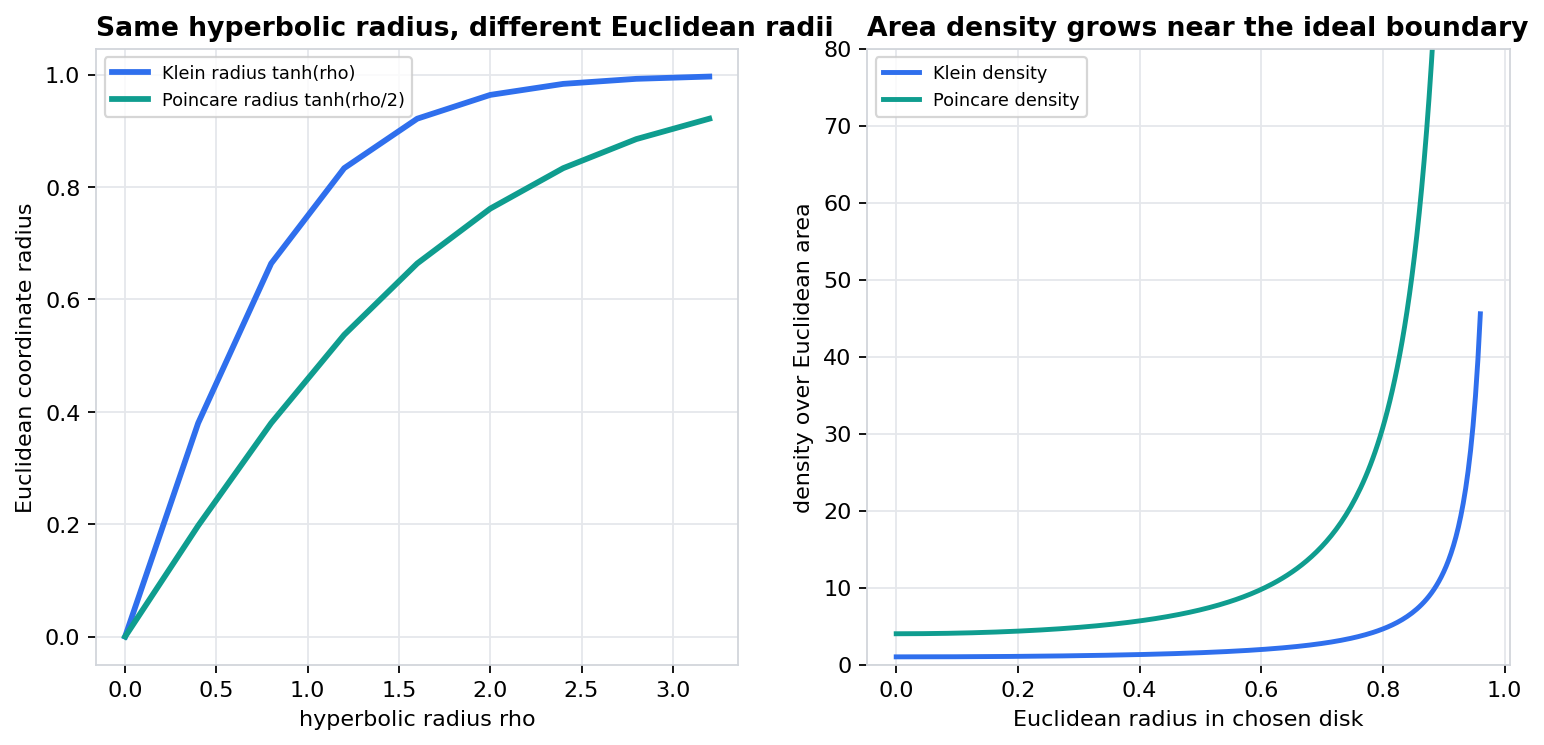

[hyperbolic-area-growth.csv](D:/Geometry/Geometry-II/artifacts/chapter-19/tables/hyperbolic-area-growth.csv)

`artifacts/chapter-19/checks/hyperbolic-area-model-checks.json`

In [7]:
rho = np.linspace(0.0, 3.2, 9)
klein_radius = np.tanh(rho)
poincare_radius = np.tanh(rho / 2.0)
hyperbolic_area = 2.0 * math.pi * (np.cosh(rho) - 1.0)
klein_euclidean_area = math.pi * klein_radius**2
poincare_euclidean_area = math.pi * poincare_radius**2

rows = []
for values in zip(rho, klein_radius, poincare_radius, hyperbolic_area, klein_euclidean_area, poincare_euclidean_area):
    rows.append({
        "hyperbolic_radius": round(float(values[0]), 6),
        "klein_euclidean_radius": round(float(values[1]), 6),
        "poincare_euclidean_radius": round(float(values[2]), 6),
        "hyperbolic_area": round(float(values[3]), 6),
        "klein_euclidean_disk_area": round(float(values[4]), 6),
        "poincare_euclidean_disk_area": round(float(values[5]), 6),
    })
area_table_path = TABLE_ROOT / "hyperbolic-area-growth.csv"
save_csv(rows, area_table_path)
generated_artifacts.append(area_table_path)

r = np.linspace(0.0, 0.96, 240)
klein_density = (1.0 - r**2) ** (-1.5)
poincare_density = 4.0 * (1.0 - r**2) ** (-2.0)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.0))
axes[0].plot(rho, klein_radius, color=COLORS["blue"], linewidth=2.6, label="Klein radius tanh(rho)")
axes[0].plot(rho, poincare_radius, color=COLORS["teal"], linewidth=2.6, label="Poincare radius tanh(rho/2)")
axes[0].set_title("Same hyperbolic radius, different Euclidean radii", loc="left", fontsize=12, fontweight="bold")
axes[0].set_xlabel("hyperbolic radius rho")
axes[0].set_ylabel("Euclidean coordinate radius")
axes[0].grid(True, color="#e5e7eb")
axes[0].legend(fontsize=8)

axes[1].plot(r, klein_density, color=COLORS["blue"], linewidth=2.2, label="Klein density")
axes[1].plot(r, poincare_density, color=COLORS["teal"], linewidth=2.2, label="Poincare density")
axes[1].set_title("Area density grows near the ideal boundary", loc="left", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Euclidean radius in chosen disk")
axes[1].set_ylabel("density over Euclidean area")
axes[1].set_ylim(0, 80)
axes[1].grid(True, color="#e5e7eb")
axes[1].legend(fontsize=8)
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("#d1d5db")

area_path = FIGURE_ROOT / "hyperbolic-area-density-model-artifacts.png"
save_figure(fig, area_path)
generated_artifacts.append(area_path)

R = sp.symbols("R", positive=True)
klein_area_R = 2 * sp.pi * (1 / sp.sqrt(1 - R**2) - 1)
poincare_area_R = 4 * sp.pi * R**2 / (1 - R**2)
klein_area_from_rho = 2 * math.pi * (1.0 / np.sqrt(1.0 - klein_radius**2) - 1.0)
poincare_area_from_rho = 4 * math.pi * poincare_radius**2 / (1.0 - poincare_radius**2)
area_checks = {
    "klein_density_integral": str(klein_area_R),
    "poincare_density_integral": str(poincare_area_R),
    "max_klein_area_vs_hyperbolic_radius_residual": float(np.max(np.abs(klein_area_from_rho - hyperbolic_area))),
    "max_poincare_area_vs_hyperbolic_radius_residual": float(np.max(np.abs(poincare_area_from_rho - hyperbolic_area))),
    "area_at_largest_sample_radius": float(hyperbolic_area[-1]),
    "klein_density_at_0_96": float(klein_density[-1]),
    "poincare_density_at_0_96": float(poincare_density[-1]),
}
computed_checks["measure_area"] = area_checks
area_check_path = CHECK_ROOT / "hyperbolic-area-model-checks.json"
save_json(area_checks, area_check_path)
generated_artifacts.append(area_check_path)

show_artifact(area_path)
show_artifact(area_table_path)
show_artifact(area_check_path)

## Reading The Checks As A Mini-Proof

The notebook does not replace the chapter proofs, but it makes their moving parts explicit. The elliptic check verifies the quotient rule before any hyperbolic model appears. The Klein-Poincare check verifies a coordinate change and the boundary-orthogonality condition that characterizes conformal disk geodesics. The isometry check separates intrinsic distance from Euclidean drawing data. The area check compares two density formulas after both are expressed in the same hyperbolic radius. Read these checks in that order: quotient, model change, isometry, measure. That order mirrors the chapter's progression from definitions to transported structures.

## Applied Lab: Break The Model, Not The Geometry

Try these edits after running the notebook once:

1. Move `k_a` and `k_b` in the Klein-Poincare comparison. The chord should remain straight on the left, and its image should still lie on a circle orthogonal to the boundary on the right.
2. Change `shift` and `angle` in the disk isometry cell. Hyperbolic distance residuals should remain small as long as `abs(shift) < 1`.
3. Compare Euclidean disk areas in the CSV with hyperbolic area. The discrepancy is not an error; it is evidence that Euclidean area in a chart is not the invariant measure.
4. Replace the Mobius map with an arbitrary affine map of the disk. The Euclidean picture may still look plausible, but the hyperbolic distance check should fail.

This is the chapter's core habit: a model is useful because it exposes some quantities, but it also introduces artifacts. The check tells which side of that line a quantity belongs to.

## Takeaways

- Elliptic geometry is the unit sphere with antipodal lifts identified; the absolute value in `arccos(abs(x dot y))` is the metric trace of that quotient.
- The Klein and Poincare disks can represent the same hyperbolic plane while drawing geodesics differently.
- Circular Poincare geodesics are not arbitrary circles: they meet the ideal boundary orthogonally.
- Disk isometries preserve hyperbolic distance and angles, but they need not preserve Euclidean chord lengths, radii, or visual straightness.
- Hyperbolic area growth near the boundary is an invariant phenomenon; the Euclidean density formula depends on the chosen model.

In [8]:
# Final sanity checks: artifacts, residual tolerances, and a compact machine-readable summary.
assert generated_artifacts, "the notebook should generate artifacts"
assert_artifacts(generated_artifacts, min_bytes=64)

assert computed_checks["elliptic_quotient"]["elliptic_distance_x_to_minus_x"] < 1e-12
assert computed_checks["elliptic_quotient"]["elliptic_distance_sign_invariance_residual"] < 1e-12
assert computed_checks["klein_poincare_models"]["klein_to_poincare_roundtrip_max"] < 1e-12
assert abs(computed_checks["klein_poincare_models"]["poincare_arc_boundary_orthogonality_residual"]) < 1e-12
assert abs(computed_checks["klein_poincare_models"]["distance_model_residual"]) < 1e-12
assert computed_checks["disk_isometries"]["max_hyperbolic_distance_residual"] < 1e-12
assert computed_checks["disk_isometries"]["max_euclidean_distance_change"] > 1e-3
assert abs(computed_checks["disk_isometries"]["hyperbolic_law_of_cosines_residual_at_origin"]) < 1e-12
assert computed_checks["measure_area"]["max_klein_area_vs_hyperbolic_radius_residual"] < 1e-10
assert computed_checks["measure_area"]["max_poincare_area_vs_hyperbolic_radius_residual"] < 1e-10

final_sanity = {
    "artifact_count_before_final_json": len(generated_artifacts),
    "artifact_root": relative_to_book(ARTIFACT_ROOT, BOOK_ROOT),
    "checks": computed_checks,
    "all_artifacts_exist": all(path.exists() for path in generated_artifacts),
    "all_artifacts_nonzero": all(path.stat().st_size > 64 for path in generated_artifacts),
}
final_sanity_path = CHECK_ROOT / "chapter-19-final-sanity.json"
save_json(final_sanity, final_sanity_path)
generated_artifacts.append(final_sanity_path)
assert_artifacts(generated_artifacts, min_bytes=64)
final_sanity["final_artifact_count"] = len(generated_artifacts)
final_sanity

{'artifact_count_before_final_json': 11,
 'artifact_root': 'artifacts/chapter-19',
 'checks': {'elliptic_quotient': {'spherical_distance_x_to_minus_x': 3.141592653589793,
   'elliptic_distance_x_to_minus_x': 0.0,
   'elliptic_distance_xy': 1.0337432920253504,
   'elliptic_distance_sign_invariance_residual': 0.0,
   'elliptic_diameter_sample_pi_over_2': 1.5707963267948966},
  'klein_poincare_models': {'klein_to_poincare_roundtrip_max': 1.2412670766236366e-16,
   'poincare_arc_circle_equation_max_abs': 8.881784197001252e-16,
   'poincare_arc_boundary_orthogonality_residual': 3.552713678800501e-15,
   'klein_distance_AB': 2.026508480368543,
   'poincare_distance_mapped_AB': 2.026508480368543,
   'distance_model_residual': 0.0},
  'disk_isometries': {'mobius_parameter_a': [0.28, -0.18],
   'mobius_rotation_angle': 0.86,
   'pair_labels': ['AB', 'BC', 'CA'],
   'hyperbolic_distances_before': [1.937655516813701,
    1.8906499659141034,
    2.2124848432135926],
   'hyperbolic_distances_after'